In [2]:
import pandas as pd

df = pd.read_csv("../dataset/archive/marketing_campaign.csv", sep=";")
print(df.shape)
df.head()


(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [5]:
print(df.isnull().sum())


Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [6]:
print(df.isnull().values.any())


True


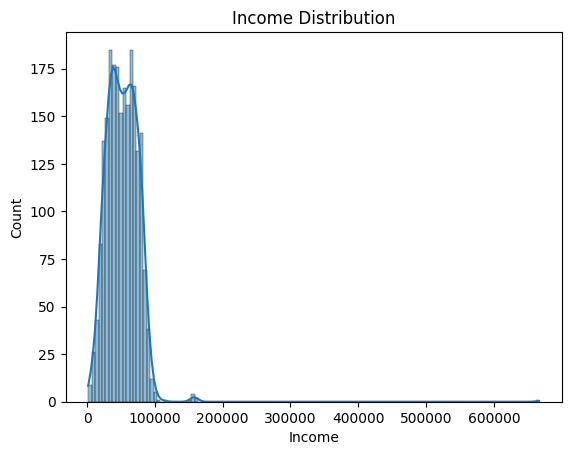

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Income"], kde=True)
plt.title("Income Distribution")
plt.show()


In [9]:
df["Income"].describe(percentiles=[0.95, 0.99])


count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
50%       51381.500000
95%       84130.000000
99%       94458.800000
max      666666.000000
Name: Income, dtype: float64

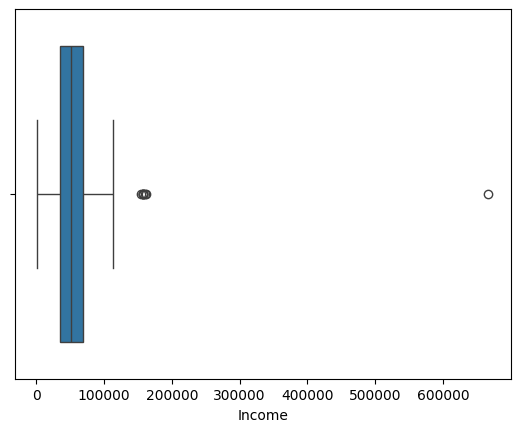

In [10]:
import seaborn as sns
sns.boxplot(x=df["Income"])
plt.show()


In [11]:
import numpy as np
df["Income_log"] = np.log1p(df["Income"])


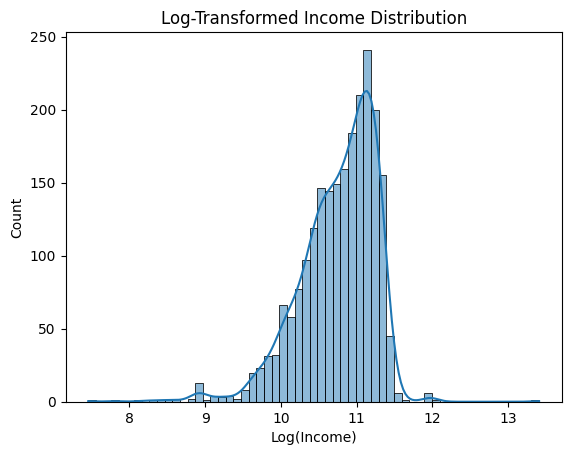

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Income_log"], kde=True)
plt.title("Log-Transformed Income Distribution")
plt.xlabel("Log(Income)")
plt.show()


In [14]:
df["Income_log"].describe()


count    2216.000000
mean       10.753825
std         0.505844
min         7.456455
25%        10.471751
50%        10.847053
75%        11.134924
max        13.410046
Name: Income_log, dtype: float64

In [15]:
spend_cols = [
    "MntWines","MntFruits","MntMeatProducts",
    "MntFishProducts","MntSweetProducts","MntGoldProds"
]

df["Total_Spending"] = df[spend_cols].sum(axis=1)


In [16]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]


In [17]:
import datetime
current_year = datetime.datetime.now().year
df["Age"] = current_year - df["Year_Birth"]


In [18]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
df["Customer_Days"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days


In [19]:
df = df.drop(columns=["Z_CostContact", "Z_Revenue"])


In [20]:
df["Age"] = current_year - df["Year_Birth"]
df = df.drop(columns=["Year_Birth"])


In [21]:
df = df.drop(columns=spend_cols)


In [22]:
df["Marital_Status"].value_counts()


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [23]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Education            2240 non-null   object        
 1   Marital_Status       2240 non-null   object        
 2   Income               2216 non-null   float64       
 3   Kidhome              2240 non-null   int64         
 4   Teenhome             2240 non-null   int64         
 5   Dt_Customer          2240 non-null   datetime64[ns]
 6   Recency              2240 non-null   int64         
 7   NumDealsPurchases    2240 non-null   int64         
 8   NumWebPurchases      2240 non-null   int64         
 9   NumCatalogPurchases  2240 non-null   int64         
 10  NumStorePurchases    2240 non-null   int64         
 11  NumWebVisitsMonth    2240 non-null   int64         
 12  AcceptedCmp3         2240 non-null   int64         
 13  AcceptedCmp4         2240 non-nul

In [24]:
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Income_log,Total_Spending,Total_Children,Age,Customer_Days
0,Graduation,Single,58138.0,0,0,2012-09-04,58,3,8,10,...,0,0,0,0,1,10.970592,1617,0,69,4916
1,Graduation,Single,46344.0,1,1,2014-03-08,38,2,1,1,...,0,0,0,0,0,10.743869,27,2,72,4366
2,Graduation,Together,71613.0,0,0,2013-08-21,26,1,8,2,...,0,0,0,0,0,11.179046,776,0,61,4565
3,Graduation,Together,26646.0,1,0,2014-02-10,26,2,2,0,...,0,0,0,0,0,10.190432,53,1,42,4392
4,PhD,Married,58293.0,1,0,2014-01-19,94,5,5,3,...,0,0,0,0,0,10.973254,422,1,45,4414


In [25]:
df["Income_log"] = df["Income_log"].fillna(df["Income_log"].median())


In [26]:
df = df.drop(columns=["Income"])


In [27]:
df = df.drop(columns=["Dt_Customer"])


In [28]:
df = df.drop(columns=["Kidhome", "Teenhome"])


In [29]:
df.nunique().sort_values()


AcceptedCmp1              2
Response                  2
Complain                  2
AcceptedCmp2              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp3              2
Total_Children            4
Education                 5
Marital_Status            8
NumCatalogPurchases      14
NumStorePurchases        14
NumDealsPurchases        15
NumWebPurchases          15
NumWebVisitsMonth        16
Age                      59
Recency                 100
Customer_Days           663
Total_Spending         1054
Income_log             1975
dtype: int64

In [30]:
for col in df.columns:
    print(f"\n🔹 {col}")
    print(df[col].unique())



🔹 Education
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

🔹 Marital_Status
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']

🔹 Recency
[58 38 26 94 16 34 32 19 68 11 59 82 53 23 51 20 91 86 41 42 63  0 69 89
  4 96 56 31  8 55 37 76 99  3 88 80 72 24 92 39 29  2 54 57 30 12 18 75
 90  1 25 40  9 87  5 95 48 70 79 45 84 44 43 35 15 17 46 27 74 85 65 13
 83 10 21 61 73 47 36 49 28 64 98 78 77 81 14 52 93 50 60 66 97 62  6 33
 67 22 71  7]

🔹 NumDealsPurchases
[ 3  2  1  5  4 15  7  0  6  9 12  8 10 13 11]

🔹 NumWebPurchases
[ 8  1  2  5  6  7  4  3 11  0 27 10  9 23 25]

🔹 NumCatalogPurchases
[10  1  2  0  3  4  6 28  9  5  8  7 11 22]

🔹 NumStorePurchases
[ 4  2 10  6  7  0  3  8  5 12  9 13 11  1]

🔹 NumWebVisitsMonth
[ 7  5  4  6  8  9 20  2  3  1 10  0 14 19 17 13]

🔹 AcceptedCmp3
[0 1]

🔹 AcceptedCmp4
[0 1]

🔹 AcceptedCmp5
[0 1]

🔹 AcceptedCmp1
[0 1]

🔹 AcceptedCmp2
[0 1]

🔹 Complain
[0 1]

🔹 Response
[1 0]

🔹 Income_log
[10.97059197 10.74386869 11.179

In [31]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Single",
    "Divorced": "Single",
    "Widow": "Single",
    "Alone": "Single",
    "YOLO": "Single",
    "Absurd": "Single"
})


In [32]:
df = df[df["Age"] < 100]


In [33]:
df["Income_log"].isnull().sum()


np.int64(0)

In [34]:
df = pd.get_dummies(
    df,
    columns=["Education", "Marital_Status"],
    drop_first=True
)


In [35]:
df.isnull().sum().sum()


np.int64(0)

In [37]:
df.select_dtypes(include="object").columns


Index([], dtype='object')

In [38]:
X = df.copy()


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [40]:
import numpy as np

print(np.isnan(X_scaled).sum())   # must be 0
print(X_scaled.shape)


0
(2237, 23)


In [41]:
df.head()

,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,...,Income_log,Total_Spending,Total_Children,Age,Customer_Days,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Single
0,58,3,8,10,4,7,0,0,0,0,...,10.970592,1617,0,69,4916,False,True,False,False,True
1,38,2,1,1,2,5,0,0,0,0,...,10.743869,27,2,72,4366,False,True,False,False,True
2,26,1,8,2,10,4,0,0,0,0,...,11.179046,776,0,61,4565,False,True,False,False,False
3,26,2,2,0,4,6,0,0,0,0,...,10.190432,53,1,42,4392,False,True,False,False,False
4,94,5,5,3,6,5,0,0,0,0,...,10.973254,422,1,45,4414,False,False,False,True,False


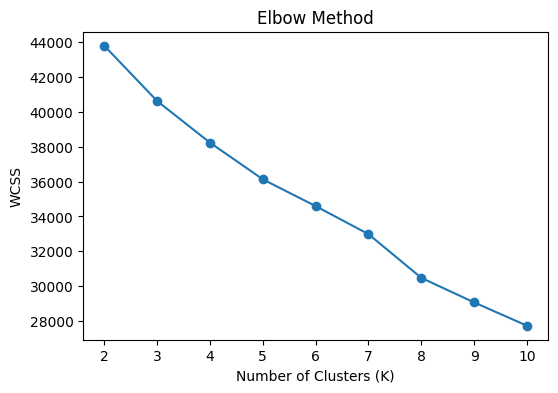

In [42]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


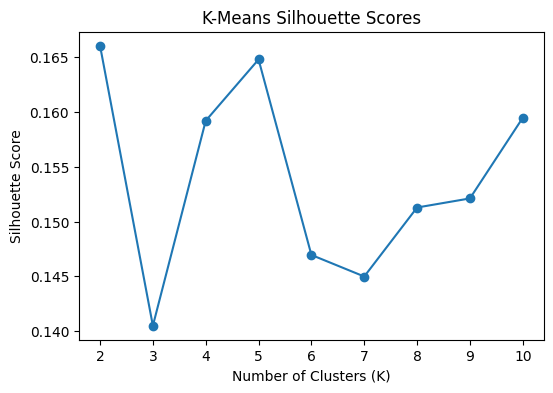

Best K (silhouette): 2


In [43]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.show()

print("Best K (silhouette):", K_range[sil_scores.index(max(sil_scores))])


In [44]:
best_k = K_range[sil_scores.index(max(sil_scores))]

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)


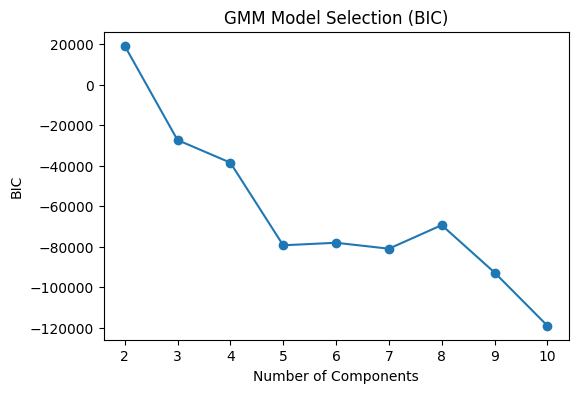

Best GMM components: 10


In [45]:
from sklearn.mixture import GaussianMixture

bic_scores = []
K_range = range(2, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.figure(figsize=(6,4))
plt.plot(K_range, bic_scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("GMM Model Selection (BIC)")
plt.show()

print("Best GMM components:", K_range[bic_scores.index(min(bic_scores))])


In [46]:
best_gmm_k = K_range[bic_scores.index(min(bic_scores))]

gmm_final = GaussianMixture(n_components=best_gmm_k, random_state=42)
gmm_labels = gmm_final.fit_predict(X_scaled)


In [47]:
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
gmm_sil = silhouette_score(X_scaled, gmm_labels)

print("K-Means Silhouette:", kmeans_sil)
print("GMM Silhouette:", gmm_sil)


K-Means Silhouette: 0.16603344725162805
GMM Silhouette: 0.1441733114684786


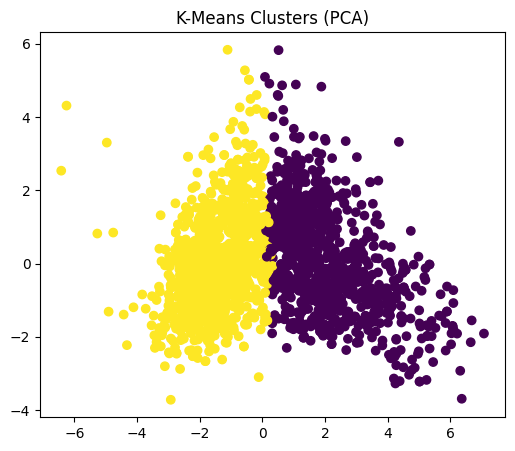

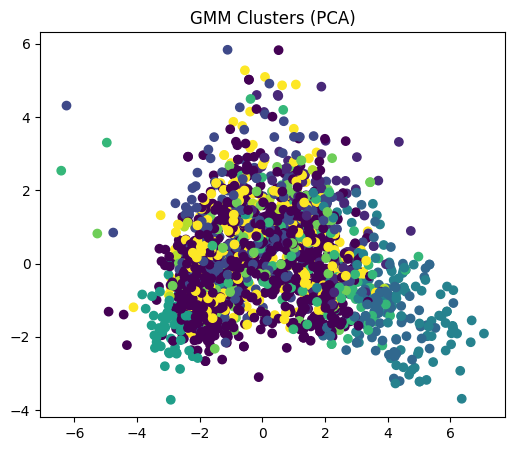

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clusters (PCA)")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels)
plt.title("GMM Clusters (PCA)")
plt.show()


In [50]:
df_final = df.copy()
df_final["KMeans_Cluster"] = kmeans_labels
df_final["GMM_Cluster"] = gmm_labels


In [51]:
from sklearn.mixture import GaussianMixture

gmm_2 = GaussianMixture(
    n_components=2,
    covariance_type="full",   # best default
    random_state=42
)

gmm_labels_2 = gmm_2.fit_predict(X_scaled)


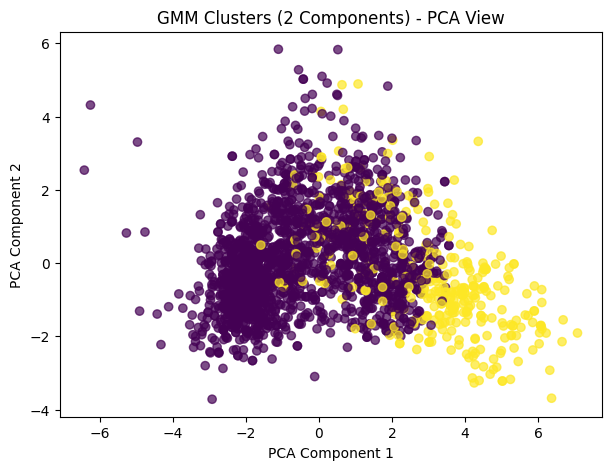

In [52]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels_2,
    alpha=0.7
)
plt.title("GMM Clusters (2 Components) - PCA View")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()
